# Week 3 — Fitting a Linear Model 

**Maths for Data Science II**

 This notebook works through the full argument on `patients_cross_section_2026.csv`:

1. Fitting `sbp ~ age + bmi + chol` by OLS
2. A complete diagnostic battery: normality, homoscedasticity, collinearity, functional form, influence


## 1. Setup

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.dpi"] = 110

## 2. Choosing the dataset

Four datasets are available in this folder. They are not interchangeable — the data *structure* dictates which estimator is valid.

| File | Structure | Suitable for plain OLS? |
|---|---|---|
| `patients_cross_section_2026.csv` | 200 patients, one row each, single time point | **Yes** — independent observations |
| `patient1_time_series_2024_2025.csv` | 1 patient, 24 monthly observations | No — serially correlated errors |
| `panel_50patients_24months.csv` | 50 patients × 24 months | No — needs fixed/random effects |
| pooled cross-sections | repeated samples over time | Only with time dummies |

Ordinary least squares assumes **independent** errors. In the time-series and panel files, consecutive readings on the same patient are strongly dependent, so the standard errors from naive OLS would be badly understated. The cross-section is the one file where the independence assumption is defensible by construction: each row is a different person, sampled once.

In [9]:
URL = ("https://raw.githubusercontent.com/thousandoaks/Maths4DS-III/"
       "refs/heads/main/datasets/patients_cross_section_2026.csv")

df = pd.read_csv(URL)


print(f"shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

shape: 200 rows x 8 columns


,patient_id,age,sex,smoker,bmi,sbp,chol,cost
0,1,25,0,1,27.8000,123.0000,218.0000,379.2900
1,2,66,1,1,28.1000,144.0000,238.0000,"1,724.0200"
2,3,59,0,0,27.1000,143.0000,204.0000,705.5300
3,4,46,1,0,20.3000,142.0000,205.0000,506.1800
4,5,45,0,0,16.8000,116.0000,187.0000,852.5400


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_id,200.0000,100.5000,57.8792,1.0000,50.7500,100.5000,150.2500,200.0000
age,200.0000,50.0450,16.4928,20.0000,36.7500,50.0000,65.0000,79.0000
sex,200.0000,0.4600,0.4996,0.0000,0.0000,0.0000,1.0000,1.0000
smoker,200.0000,0.2600,0.4397,0.0000,0.0000,0.0000,1.0000,1.0000
bmi,200.0000,25.7910,3.9888,14.1000,23.1750,25.8500,28.2000,36.4000
sbp,200.0000,136.9050,12.4123,104.0000,128.0000,138.0000,145.0000,177.0000
chol,200.0000,220.0250,23.5691,146.0000,205.0000,219.0000,235.2500,304.0000
cost,200.0000,877.5163,513.2045,216.3300,526.4800,732.1100,"1,048.5525","3,025.8900"


## 3. Statistical Distrubution of Variables
We screen the candidate response variables. Shapiro–Wilk tests the null hypothesis that the sample is drawn from a normal distribution — a **large** $p$-value means we fail to reject normality, which here is the outcome we want.

In [11]:
rows = []
for col in ["age", "bmi", "sbp", "chol", "cost"]:
    x = df[col]
    sw = stats.shapiro(x)
    rows.append({
        "variable": col,
        "mean": x.mean(),
        "std": x.std(),
        "skew": stats.skew(x),
        "excess kurtosis": stats.kurtosis(x),
        "Shapiro W": sw.statistic,
        "Shapiro p": sw.pvalue,
        "normal?": "yes" if sw.pvalue > 0.05 else "NO",
    })

normality = pd.DataFrame(rows).set_index("variable")
normality

,mean,std,skew,excess kurtosis,Shapiro W,Shapiro p,normal?
variable,,,,,,,
age,50.0450,16.4928,-0.0850,-1.1341,0.9582,0.0000,NO
bmi,25.7910,3.9888,-0.1275,0.0515,0.9957,0.8409,yes
sbp,136.9050,12.4123,0.1491,0.0927,0.9945,0.6756,yes
chol,220.0250,23.5691,-0.0156,0.6292,0.9941,0.6199,yes
cost,877.5163,513.2045,1.7367,3.6506,0.8468,0.0000,NO


Reading this table carefully:

- **`sbp`, `chol`, `bmi`** are all comfortably consistent with normality ($p > 0.6$), with skew near zero.
- **`cost`** is emphatically not: skew $\approx 1.7$, $p < 0.001$. It is a strictly positive, right-skewed monetary variable — the classic case for a log transform or a Gamma GLM.
- **`age`** also fails, but this is a red herring. It is approximately *uniform* on [20, 80] by design. Age is a **predictor**, and predictors face no distributional assumption whatsoever. A failed normality test on a regressor is not a problem.

**We take **`sbp`** as the response and **`age`, `bmi`, `chol`** as quantitative regressors.**

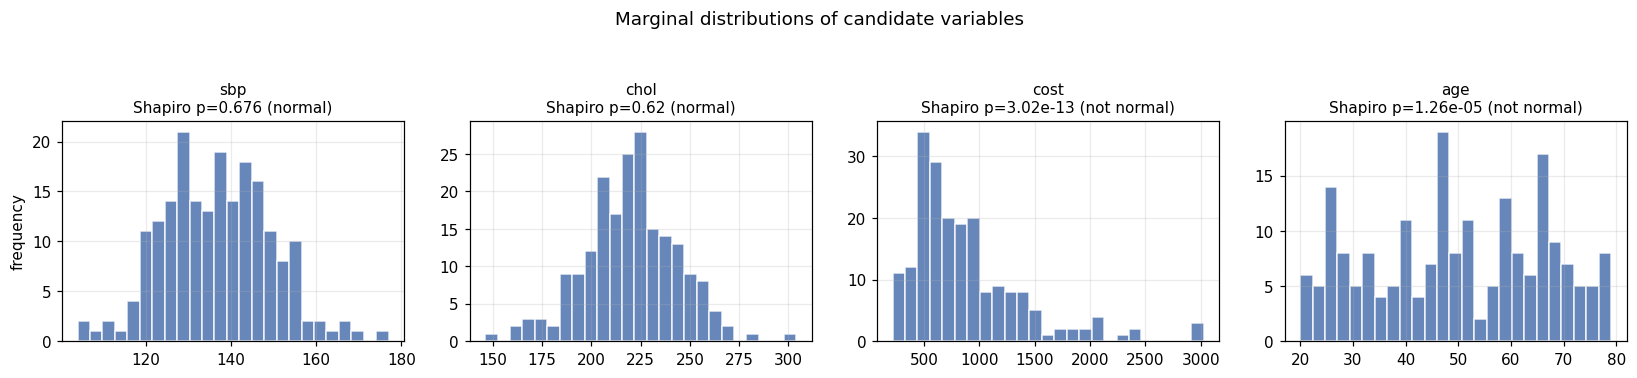

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, col in zip(axes, ["sbp", "chol", "cost", "age"]):
    ax.hist(df[col], bins=25, color="#4C72B0", edgecolor="white", alpha=.85)
    p = stats.shapiro(df[col]).pvalue
    verdict = "normal" if p > .05 else "not normal"
    ax.set_title(f"{col}\nShapiro p={p:.3g} ({verdict})", fontsize=10)
    ax.grid(alpha=.25)
axes[0].set_ylabel("frequency")
fig.suptitle("Marginal distributions of candidate variables", y=1.06, fontsize=12)
plt.tight_layout()
plt.show()

### Correlation structure

Before fitting, check that the regressors relate to the response but not excessively to each other.

         age     bmi   chol    sbp
age   1.0000 -0.0030 0.3590 0.6180
bmi  -0.0030  1.0000 0.2560 0.3270
chol  0.3590  0.2560 1.0000 0.4080
sbp   0.6180  0.3270 0.4080 1.0000


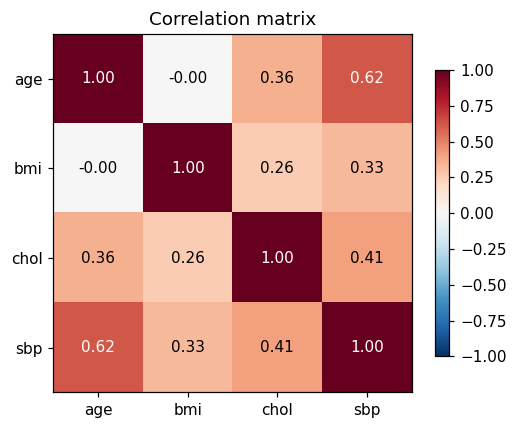

In [13]:
corr = df[["age", "bmi", "chol", "sbp"]].corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns)
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.6 else "black", fontsize=10)
fig.colorbar(im, ax=ax, shrink=.8)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

`age`–`sbp` is the strongest association at 0.62; `bmi` and `chol` contribute 0.33 and 0.41. Critically, `age`–`bmi` is essentially **0.00**, so the regressors carry largely non-overlapping information. That is a good sign for a well-conditioned design matrix.

## 4. Fitting the model

$$ \texttt{sbp}_i = \beta_0 + \beta_1\,\texttt{age}_i + \beta_2\,\texttt{bmi}_i + \beta_3\,\texttt{chol}_i + \varepsilon_i $$

Note `sm.add_constant` — statsmodels does not include an intercept unless you ask for one.

In [14]:
predictors = ["age", "bmi", "chol"]
X = sm.add_constant(df[predictors])
y = df["sbp"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    sbp   R-squared:                       0.503
Model:                            OLS   Adj. R-squared:                  0.495
Method:                 Least Squares   F-statistic:                     66.03
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           1.50e-29
Time:                        18:34:59   Log-Likelihood:                -717.18
No. Observations:                 200   AIC:                             1442.
Df Residuals:                     196   BIC:                             1456.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         76.8322      6.436     11.937      0.0

### Interpretation

$$ \widehat{\texttt{sbp}} = 76.83 + 0.431\,\texttt{age} + 0.922\,\texttt{bmi} + 0.067\,\texttt{chol} $$

- Each additional **year of age** raises predicted systolic BP by **0.43 mmHg**, holding BMI and cholesterol fixed. Over a decade, ≈ 4.3 mmHg.
- Each additional **BMI point** raises it by **0.92 mmHg**. So roughly 4.7 BMI points ≈ one decade of ageing.
- The intercept (76.83 mmHg at age 0, BMI 0, cholesterol 0) is **not interpretable** — it lies far outside the data. Centring the predictors would fix this if the intercept mattered.

